## 0. Импорты, конфигурация и утилиты

In [1]:
from pathlib import Path
import os, sys, gc, math, pickle, ast, warnings, random

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
from IPython.display import display
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, mean_squared_error, mean_absolute_error,
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from torch.utils.data import DataLoader, Dataset, TensorDataset

ROOT = Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from app.ml_model import SimpleLSTM  # эталон из бейзлайна/CP5

DATA_DIR = Path(os.environ.get("ML_DATA_DIR", ROOT / "data" / "processed"))
MODELS_DIR = Path(os.environ.get("ML_MODELS_DIR", ROOT / "models"))
MODELS_DIR.mkdir(parents=True, exist_ok=True)

ACTIVE_ASSET = "BTC"
ASSETS = ["BTC", "ETH", "BNB", "SOL", "XRP"]
WINDOW_SIZE = 60
BATCH_SIZE = 256
BATCH_SIZE_HEAVY = min(BATCH_SIZE, 128)
LR = 1e-3
EPOCHS = 30
PATIENCE = 5
HIDDEN_SIZE = 64
NUM_LAYERS = 1
DROPOUT = 0.2
SEED = 42

PER_YEAR_1M = 60 * 24 * 365
PER_YEAR_15M = (60 * 24 * 365) / 15

# Транзакционные издержки (реалистично для крипто-спота, taker fee ~ 5-10 bps + проскальзывание)
FEE_BPS = 5.0          # комиссия в базисных пунктах за одну сделку (вход/выход)
SLIPPAGE_BPS = 2.0     # проскальзывание в базисных пунктах
COST_PER_TURN = (FEE_BPS + SLIPPAGE_BPS) / 1e4  # доля от позиции при смене позиции

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.cuda.set_per_process_memory_fraction(0.92)
print("device:", device)
print("models dir:", MODELS_DIR)

device: cuda
models dir: D:\study\master_ai\mastercoursework\master-coursework\models


In [ ]:
def load_splits(data_dir: Path):
    return (
        pd.read_parquet(data_dir / "X_train.parquet"),
        pd.read_parquet(data_dir / "y_train.parquet"),
        pd.read_parquet(data_dir / "X_val.parquet"),
        pd.read_parquet(data_dir / "y_val.parquet"),
        pd.read_parquet(data_dir / "X_test.parquet"),
        pd.read_parquet(data_dir / "y_test.parquet"),
    )


def resolve_y_column(df: pd.DataFrame, asset: str, name: str = "y_bin"):
    key = (asset, name)
    if key in df.columns:
        return key
    for c in df.columns:
        if c == key:
            return c
        if isinstance(c, str) and c.startswith("("):
            try:
                if ast.literal_eval(c) == key:
                    return c
            except (ValueError, SyntaxError):
                pass
    raise KeyError(f"Нет таргета {key}. Примеры колонок: {list(df.columns)[:10]}")


class WindowDataset(Dataset):
    def __init__(self, X, y, window):
        self.window = window
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)
        seqs, labs = [], []
        for i in range(window, len(X)):
            seqs.append(self.X[i - window:i]); labs.append(self.y[i])
        self.sequences = np.stack(seqs, axis=0)
        self.labels = np.array(labs, dtype=np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.from_numpy(self.sequences[idx]), torch.tensor(self.labels[idx], dtype=torch.long)


def sharpe_ratio(log_returns, periods_per_year):
    log_returns = pd.Series(log_returns)
    if len(log_returns) == 0 or log_returns.std() == 0:
        return 0.0
    return float(log_returns.mean() / log_returns.std() * np.sqrt(periods_per_year))


def triple_barrier_labels(r, vol_window, pt_mult, sl_mult, vertical, eps=1e-8):
    r = r.astype(float).sort_index()
    vals = r.values; n = len(vals)
    out = np.full(n, np.nan)
    for pos in range(vol_window, n - vertical + 1):
        sig = float(vals[pos - vol_window:pos].std()) or eps
        if sig < eps: sig = eps
        upper, lower = pt_mult * sig, -sl_mult * sig
        cum, lab = 0.0, 0
        for k in range(vertical):
            cum += vals[pos + k]
            if cum >= upper: lab = 1; break
            if cum <= lower: lab = 0; break
        else:
            lab = 0
        out[pos] = lab
    return pd.Series(out, index=r.index)


def train_epoch(model, loader, criterion, optimizer):
    model.train(); tot, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward(); optimizer.step()
        tot += loss.item() * xb.size(0); n += xb.size(0)
    return tot / max(n, 1)


@torch.no_grad()
def roc_auc_logits(model, loader):
    model.eval(); ys, sc = [], []
    for xb, yb in loader:
        ys.append(yb.numpy()); sc.append(model(xb.to(device))[:, 1].cpu().numpy())
    if not ys: return 0.5
    try:
        return roc_auc_score(np.concatenate(ys), np.concatenate(sc))
    except ValueError:
        return 0.5


@torch.no_grad()
def predict_labels_probs(model, loader):
    model.eval(); preds, ys, probs = [], [], []
    for xb, yb in loader:
        logits = model(xb.to(device))
        probs.append(torch.softmax(logits, 1)[:, 1].cpu().numpy())
        preds.append(torch.argmax(logits, 1).cpu().numpy())
        ys.append(yb.numpy())
    return np.concatenate(preds), np.concatenate(ys), np.concatenate(probs)


def fit_classifier(model, train_loader, val_loader, criterion, optimizer,
                   epochs=EPOCHS, patience=PATIENCE, tag=""):
    """Обучение с early stopping по val ROC-AUC (как в CP5)."""
    best_auc, best_state, stale = -1.0, None, 0
    for ep in range(1, epochs + 1):
        tl = train_epoch(model, train_loader, criterion, optimizer)
        va = roc_auc_logits(model, val_loader)
        print(f"[{tag}] {ep:02d}/{epochs} loss={tl:.4f} val_auc={va:.4f}")
        if va > best_auc:
            best_auc, best_state, stale = va, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            stale += 1
            if stale >= patience:
                print(f"[{tag}] early stopping"); break
    if best_state is not None:
        model.load_state_dict(best_state)
    return best_auc


# --- Сохранение моделей в MODELS_DIR с осмысленными именами ---
def _infer_input_size(model, default=None):
    """Безопасно определяет input_size из самой модели (первый LSTM/Linear),
    не обращаясь к глобальным переменным и к model.<attr>."""
    for m in model.modules():
        if isinstance(m, nn.LSTM):
            return int(m.input_size)
    for m in model.modules():
        if isinstance(m, nn.Linear):
            return int(m.in_features)
    return default


def _infer_hidden_size(model, default=None):
    for m in model.modules():
        if isinstance(m, nn.LSTM):
            return int(m.hidden_size)
    return default


def save_torch_model(model, filename, extra=None):
    """Сохраняет state_dict torch-модели + метаданные в models/<filename>.

    Размеры берём из самой модели (а не из глобальных переменных), чтобы избежать
    AttributeError '... object has no attribute n_features' при разных способах запуска.
    """
    path = MODELS_DIR / filename
    payload = {"state_dict": model.state_dict(),
               "class_name": type(model).__name__,
               "input_size": _infer_input_size(model, default=globals().get("n_features")),
               "window_size": globals().get("WINDOW_SIZE"),
               "hidden_size": _infer_hidden_size(model, default=globals().get("HIDDEN_SIZE"))}
    if extra:
        payload.update(extra)
    torch.save(payload, path)
    print(f"[saved] {path}")
    return path


def save_sklearn_model(model, filename, extra=None):
    """Сохраняет sklearn-модель (+ метаданные) в models/<filename>.pkl"""
    path = MODELS_DIR / filename
    with open(path, "wb") as f:
        pickle.dump({"model": model, "meta": extra or {}}, f)
    print(f"[saved] {path}")
    return path

## 1. Реалистичная оценка с транзакционными издержками

In [3]:
def net_returns(positions: pd.Series, asset_returns: pd.Series, cost_per_turn=COST_PER_TURN):
    """Чистая доходность стратегии long/flat с учётом издержек на смену позиции.
    positions: 0/1 (или доля капитала) на каждый шаг; asset_returns: log-returns актива.
    """
    positions = positions.reindex(asset_returns.index).fillna(0.0)
    gross = positions * asset_returns
    turn = positions.diff().abs().fillna(positions.abs())   # объём переключений
    cost = turn * cost_per_turn
    return gross - cost


def evaluate_strategy(positions, asset_returns, periods_per_year, name="strategy",
                      prob=None, true_label=None):
    """Информативная оценка торговой стратегии с жёстким выравниванием индексов.

    ВАЖНО (исправление бага): раньше при рассинхроне длин positions и asset_returns
    reindex тихо заполнял NaN нулями → метрики "схлопывались" в 0 или в Buy&Hold.
    Теперь работаем только по общему индексу и диагностируем вырожденные позиции.
    """
    positions = pd.Series(positions).astype(float)
    asset_returns = pd.Series(asset_returns).astype(float)
    common = positions.index.intersection(asset_returns.index)
    if len(common) == 0:
        # индексы не совпадают — выравниваем позиционно (одинаковый порядок)
        m = min(len(positions), len(asset_returns))
        positions = pd.Series(positions.values[:m], index=asset_returns.index[:m])
        common = positions.index
    pos = positions.reindex(common).fillna(0.0)
    ret = asset_returns.reindex(common).fillna(0.0)

    gross = pos * ret
    turn = pos.diff().abs().fillna(pos.abs())
    net = gross - turn * COST_PER_TURN
    n_trades = int(turn.sum())

    frac_long = float((pos > 0).mean())
    n_unique_pos = int(pd.unique(np.round(pos.values, 4)).size)
    degenerate = (n_unique_pos <= 1)   # позиция не меняется → или всё 0 (Sharpe~0), или всё 1 (=B&H)

    res = {
        "Стратегия": name,
        "Sharpe gross": round(sharpe_ratio(gross, periods_per_year), 4),
        "Sharpe net": round(sharpe_ratio(net, periods_per_year), 4),
        "PnL net (sum logret)": round(float(net.sum()), 5),
        "% времени в long": round(100 * frac_long, 1),
        "Сделок (смен позиции)": n_trades,
        "Вырождена?": "ДА" if degenerate else "нет",
    }
    if prob is not None and true_label is not None:
        prob = np.asarray(prob); true_label = np.asarray(true_label)
        try:
            res["ROC-AUC"] = round(float(roc_auc_score(true_label, prob)), 4)
        except ValueError:
            res["ROC-AUC"] = float("nan")
        # hit-rate на входах: доля прибыльных ставок (ret>0 там, где были в long)
        in_pos = pos.values > 0
        if in_pos.sum() > 0:
            res["Hit-rate входов"] = round(100 * float((ret.values[in_pos] > 0).mean()), 1)
        else:
            res["Hit-rate входов"] = float("nan")
    return res

## 2. Данные и triple-barrier разметка (как лучший таргет checkpoint 5)

In [4]:
X_train, y_train, X_val, y_val, X_test, y_test = load_splits(DATA_DIR)

prefix = f"{ACTIVE_ASSET}__"
feat_cols = [c for c in X_train.columns if str(c).startswith(prefix)]
n_features = len(feat_cols)

# --- triple-barrier (минутные log-returns y_reg) ---
VOL_WINDOW_TB, PT_MULT, SL_MULT, VERTICAL_TB = 60, 1.0, 1.0, 15

s_tr = y_train[resolve_y_column(y_train, ACTIVE_ASSET, "y_reg")].dropna()
s_va = y_val[resolve_y_column(y_val, ACTIVE_ASSET, "y_reg")].dropna()
s_te = y_test[resolve_y_column(y_test, ACTIVE_ASSET, "y_reg")].dropna()

tb_tr = triple_barrier_labels(s_tr, VOL_WINDOW_TB, PT_MULT, SL_MULT, VERTICAL_TB)
tb_va = triple_barrier_labels(s_va, VOL_WINDOW_TB, PT_MULT, SL_MULT, VERTICAL_TB)
tb_te = triple_barrier_labels(s_te, VOL_WINDOW_TB, PT_MULT, SL_MULT, VERTICAL_TB)

ix_tr = tb_tr.dropna().index.intersection(X_train[feat_cols].index)
ix_va = tb_va.dropna().index.intersection(X_val[feat_cols].index)
ix_te = tb_te.dropna().index.intersection(X_test[feat_cols].index)

Xt_tb = X_train[feat_cols].loc[ix_tr]; Xv_tb = X_val[feat_cols].loc[ix_va]; Xte_tb = X_test[feat_cols].loc[ix_te]
yt_tb = tb_tr.loc[ix_tr].astype(np.int64).values
yv_tb = tb_va.loc[ix_va].astype(np.int64).values
yte_tb = tb_te.loc[ix_te].astype(np.int64).values

# fit scaler ТОЛЬКО на train (без утечки)
scaler_tb = StandardScaler()
Xt_s = scaler_tb.fit_transform(Xt_tb)
Xv_s = scaler_tb.transform(Xv_tb)
Xte_s = scaler_tb.transform(Xte_tb)

ds_tr = WindowDataset(Xt_s, yt_tb, WINDOW_SIZE)
ds_va = WindowDataset(Xv_s, yv_tb, WINDOW_SIZE)
ds_te = WindowDataset(Xte_s, yte_tb, WINDOW_SIZE)
ld_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True)
ld_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False)
ld_te = DataLoader(ds_te, batch_size=BATCH_SIZE, shuffle=False)

ct = np.bincount(ds_tr.labels, minlength=2)
cw = ct.sum() / (2 * np.maximum(ct, 1))
w_tb = torch.tensor(cw, dtype=torch.float32)

# фактическая минутная доходность на test для расчёта Sharpe/PnL (выровнено по окнам)
idx_te = Xte_tb.index[WINDOW_SIZE: WINDOW_SIZE + len(ds_te)]
y_reg_te = y_test[resolve_y_column(y_test, ACTIVE_ASSET, "y_reg")].reindex(idx_te).fillna(0.0)
idx_va_w = Xv_tb.index[WINDOW_SIZE: WINDOW_SIZE + len(ds_va)]
y_reg_va = y_val[resolve_y_column(y_val, ACTIVE_ASSET, "y_reg")].reindex(idx_va_w).fillna(0.0)

display(pd.DataFrame([{
    "n_features": n_features, "train_windows": len(ds_tr),
    "val_windows": len(ds_va), "test_windows": len(ds_te),
    "class_counts": ct.tolist(),
}]))

# Buy & Hold с учётом издержек (1 сделка на вход) — референс
bh_pos = pd.Series(1.0, index=idx_te)
bh_eval = evaluate_strategy(bh_pos, y_reg_te, PER_YEAR_1M, name="#0 Buy & Hold")
display(pd.DataFrame([bh_eval]))

,n_features,train_windows,val_windows,test_windows,class_counts
0,15,348347,175546,1304,"[174683, 173664]"


,Стратегия,Sharpe gross,Sharpe net,PnL net (sum logret),% времени в long,Сделок (смен позиции),Вырождена?
0,#0 Buy & Hold,10.045,9.4591,0.01105,100.0,1,ДА


## 3. Self-Supervised предобучение: masked reconstruction

**Идея.** На крипторынке размеченные таргеты слабопредсказуемы (ROC-AUC ~0.51), но *самих окон* очень много. Self-supervised learning (SSL) позволяет выучить полезное представление временного ряда **без меток**, а затем дообучить лёгкую голову на маленьком размеченном сигнале — это снижает переобучение и улучшает обобщение.

**Метод (masked reconstruction, в духе TST / BERT-for-TS).** Маскируем случайные таймстемпы во входном окне и обучаем LSTM-энкодер + линейный декодер восстанавливать исходные значения. Затем замораживаем/дообучаем энкодер и ставим классификационную голову на triple-barrier таргет.

In [5]:
class LSTMEncoder(nn.Module):
    """Общий энкодер: LSTM -> представление последовательности (h_t для каждого шага и финальное)."""
    def __init__(self, input_size, hidden_size=HIDDEN_SIZE, num_layers=1, dropout=DROPOUT):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.hidden_size = hidden_size

    def forward(self, x):
        out, _ = self.lstm(x)          # (B, T, H)
        return out                      # представления по всем шагам


class MaskedReconstructionModel(nn.Module):
    def __init__(self, input_size, hidden_size=HIDDEN_SIZE):
        super().__init__()
        self.encoder = LSTMEncoder(input_size, hidden_size)
        self.decoder = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        return self.decoder(self.encoder(x))   # реконструкция (B, T, F)


def mask_batch(xb, mask_ratio=0.15):
    """Случайно зануляем mask_ratio таймстемпов; возвращаем испорченный вход и маску."""
    B, T, Fdim = xb.shape
    mask = (torch.rand(B, T, device=xb.device) < mask_ratio).unsqueeze(-1)  # (B,T,1)
    corrupted = xb.masked_fill(mask, 0.0)
    return corrupted, mask.float()


def pretrain_masked(model, loader, epochs=15, lr=1e-3, tag="SSL-mask"):
    model.to(device); opt = optim.Adam(model.parameters(), lr=lr)
    for ep in range(1, epochs + 1):
        model.train(); tot, n = 0.0, 0
        for xb, _ in loader:
            xb = xb.to(device)
            corrupted, mask = mask_batch(xb)
            recon = model(corrupted)
            # MSE только по замаскированным позициям
            loss = ((recon - xb) ** 2 * mask).sum() / (mask.sum() * xb.size(-1) + 1e-8)
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * xb.size(0); n += xb.size(0)
        print(f"[{tag}] {ep:02d}/{epochs} recon_mse={tot / max(n,1):.5f}")
    return model.encoder


class EncoderClassifier(nn.Module):
    """Голова поверх предобученного энкодера (берём представление последнего шага)."""
    def __init__(self, encoder, hidden_size=HIDDEN_SIZE, dropout=DROPOUT, freeze_encoder=False):
        super().__init__()
        self.encoder = encoder
        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 2)

    def forward(self, x):
        h = self.encoder(x)[:, -1, :]
        return self.fc(self.dropout(h))

In [6]:
# 3.1 Предобучение (без меток) на train-окнах triple-barrier пайплайна
torch.manual_seed(SEED)
ssl_model = MaskedReconstructionModel(n_features, HIDDEN_SIZE)
ssl_encoder = pretrain_masked(ssl_model, ld_tr, epochs=15, lr=1e-3)

# 3.2 Дообучение классификационной головы на triple-barrier таргете
torch.manual_seed(SEED)
ssl_clf = EncoderClassifier(ssl_encoder, HIDDEN_SIZE, DROPOUT, freeze_encoder=False).to(device)
crit_ssl = nn.CrossEntropyLoss(weight=w_tb.to(device))
opt_ssl = optim.Adam(ssl_clf.parameters(), lr=LR)
fit_classifier(ssl_clf, ld_tr, ld_va, crit_ssl, opt_ssl, tag="SSL-finetune")

pred_ssl, ytrue_ssl, p1_ssl = predict_labels_probs(ssl_clf, ld_te)

# подбор порога по net-Sharpe на валидации (не argmax!) — учитываем издержки
_, yv_ssl, p1v_ssl = predict_labels_probs(ssl_clf, ld_va)
thr_grid = np.linspace(0.30, 0.70, 41)
best_thr_ssl, best_sh = 0.5, -1e18
for t in thr_grid:
    pos = pd.Series((p1v_ssl >= t).astype(float), index=idx_va_w)
    sh = sharpe_ratio(net_returns(pos, y_reg_va), PER_YEAR_1M)
    if sh > best_sh:
        best_sh, best_thr_ssl = sh, t

pos_ssl = pd.Series((p1_ssl >= best_thr_ssl).astype(float), index=idx_te)
ssl_eval = evaluate_strategy(pos_ssl, y_reg_te, PER_YEAR_1M,
                             name=f"#SSL masked (t={best_thr_ssl:.2f})",
                             prob=p1_ssl, true_label=ytrue_ssl)
display(pd.DataFrame([ssl_eval]))

# Сохраняем: предобученный энкодер + файнтюн-классификатор
save_torch_model(ssl_model, "ssl_masked_reconstruction_pretrain.pt")
save_torch_model(ssl_clf, "ssl_masked_finetune_classifier.pt",
                 extra={"threshold": float(best_thr_ssl)})

[SSL-mask] 01/15 recon_mse=0.30703
[SSL-mask] 02/15 recon_mse=0.26821
[SSL-mask] 03/15 recon_mse=0.26746
[SSL-mask] 04/15 recon_mse=0.26762
[SSL-mask] 05/15 recon_mse=0.26627
[SSL-mask] 06/15 recon_mse=0.26479
[SSL-mask] 07/15 recon_mse=0.26477
[SSL-mask] 08/15 recon_mse=0.26189
[SSL-mask] 09/15 recon_mse=0.26218
[SSL-mask] 10/15 recon_mse=0.26130
[SSL-mask] 11/15 recon_mse=0.26084
[SSL-mask] 12/15 recon_mse=0.25766
[SSL-mask] 13/15 recon_mse=0.25605
[SSL-mask] 14/15 recon_mse=0.25474
[SSL-mask] 15/15 recon_mse=0.25336
[SSL-finetune] 01/30 loss=0.6929 val_auc=0.5113
[SSL-finetune] 02/30 loss=0.6922 val_auc=0.5118
[SSL-finetune] 03/30 loss=0.6920 val_auc=0.5107
[SSL-finetune] 04/30 loss=0.6916 val_auc=0.5120
[SSL-finetune] 05/30 loss=0.6912 val_auc=0.5113
[SSL-finetune] 06/30 loss=0.6907 val_auc=0.5092
[SSL-finetune] 07/30 loss=0.6902 val_auc=0.5099
[SSL-finetune] 08/30 loss=0.6896 val_auc=0.5093
[SSL-finetune] 09/30 loss=0.6890 val_auc=0.5086
[SSL-finetune] early stopping


,Стратегия,Sharpe gross,Sharpe net,PnL net (sum logret),% времени в long,Сделок (смен позиции),Вырождена?,ROC-AUC,Hit-rate входов
0,#SSL masked (t=0.30),10.045,9.4591,0.01105,100.0,1,ДА,0.5529,51.8


[saved] D:\study\master_ai\mastercoursework\master-coursework\models\ssl_masked_reconstruction_pretrain.pt
[saved] D:\study\master_ai\mastercoursework\master-coursework\models\ssl_masked_finetune_classifier.pt


WindowsPath('D:/study/master_ai/mastercoursework/master-coursework/models/ssl_masked_finetune_classifier.pt')

## 4. Contrastive предобучение (NT-Xent, в духе SimCLR / TS-TCC)

**Идея.** Contrastive learning сближает представления двух аугментированных «видов» одного и того же окна и отталкивает их от других окон в батче. Для временных рядов это даёт устойчивые к шуму эмбеддинги.

**Аугментации** (из аугментаций в EDA): добавление гауссова шума, масштабирование амплитуды (jitter + scaling). Лосс — **NT-Xent** (нормализованная температурная кросс-энтропия). После предобучения энкодера ставим линейную голову (linear probing / fine-tuning) на triple-barrier таргет.

In [7]:
class ContrastiveModel(nn.Module):
    def __init__(self, input_size, hidden_size=HIDDEN_SIZE, proj_dim=64):
        super().__init__()
        self.encoder = LSTMEncoder(input_size, hidden_size)
        self.projector = nn.Sequential(
            nn.Linear(hidden_size, hidden_size), nn.ReLU(), nn.Linear(hidden_size, proj_dim)
        )

    def forward(self, x):
        h = self.encoder(x)[:, -1, :]
        z = self.projector(h)
        return F.normalize(z, dim=1)


def augment(xb, noise_std=0.05, scale_range=(0.9, 1.1)):
    noise = torch.randn_like(xb) * noise_std
    scale = torch.empty(xb.size(0), 1, 1, device=xb.device).uniform_(*scale_range)
    return xb * scale + noise


def nt_xent(z1, z2, temperature=0.5):
    """NT-Xent loss для двух батчей нормализованных эмбеддингов."""
    B = z1.size(0)
    z = torch.cat([z1, z2], dim=0)              # (2B, d)
    sim = z @ z.t() / temperature               # (2B, 2B)
    sim.fill_diagonal_(-9e15)
    targets = torch.arange(B, device=z.device)
    targets = torch.cat([targets + B, targets], dim=0)
    return F.cross_entropy(sim, targets)


def pretrain_contrastive(model, loader, epochs=15, lr=1e-3, temperature=0.5, tag="Contrastive"):
    model.to(device); opt = optim.Adam(model.parameters(), lr=lr)
    for ep in range(1, epochs + 1):
        model.train(); tot, n = 0.0, 0
        for xb, _ in loader:
            xb = xb.to(device)
            z1 = model(augment(xb)); z2 = model(augment(xb))
            loss = nt_xent(z1, z2, temperature)
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * xb.size(0); n += xb.size(0)
        print(f"[{tag}] {ep:02d}/{epochs} ntxent={tot / max(n,1):.4f}")
    return model.encoder

In [8]:
# 4.1 Contrastive предобучение энкодера (без меток)
torch.manual_seed(SEED)
con_model = ContrastiveModel(n_features, HIDDEN_SIZE, proj_dim=64)
con_encoder = pretrain_contrastive(con_model, ld_tr, epochs=15, lr=1e-3)

# 4.2 Linear probing: замораживаем энкодер, учим только голову
torch.manual_seed(SEED)
con_clf = EncoderClassifier(con_encoder, HIDDEN_SIZE, DROPOUT, freeze_encoder=True).to(device)
crit_con = nn.CrossEntropyLoss(weight=w_tb.to(device))
opt_con = optim.Adam(filter(lambda p: p.requires_grad, con_clf.parameters()), lr=LR)
fit_classifier(con_clf, ld_tr, ld_va, crit_con, opt_con, tag="Contrastive-probe")

pred_con, ytrue_con, p1_con = predict_labels_probs(con_clf, ld_te)

_, yv_con, p1v_con = predict_labels_probs(con_clf, ld_va)
best_thr_con, best_sh = 0.5, -1e18
for t in thr_grid:
    pos = pd.Series((p1v_con >= t).astype(float), index=idx_va_w)
    sh = sharpe_ratio(net_returns(pos, y_reg_va), PER_YEAR_1M)
    if sh > best_sh:
        best_sh, best_thr_con = sh, t

pos_con = pd.Series((p1_con >= best_thr_con).astype(float), index=idx_te)
con_eval = evaluate_strategy(pos_con, y_reg_te, PER_YEAR_1M,
                             name=f"#Contrastive (t={best_thr_con:.2f})",
                             prob=p1_con, true_label=ytrue_con)
display(pd.DataFrame([con_eval]))

save_torch_model(con_model, "contrastive_ntxent_pretrain.pt")
save_torch_model(con_clf, "contrastive_linear_probe_classifier.pt",
                 extra={"threshold": float(best_thr_con)})

[Contrastive] 01/15 ntxent=4.3715
[Contrastive] 02/15 ntxent=4.3060
[Contrastive] 03/15 ntxent=4.2992
[Contrastive] 04/15 ntxent=4.2961
[Contrastive] 05/15 ntxent=4.2940
[Contrastive] 06/15 ntxent=4.2929
[Contrastive] 07/15 ntxent=4.2921
[Contrastive] 08/15 ntxent=4.2915
[Contrastive] 09/15 ntxent=4.2912
[Contrastive] 10/15 ntxent=4.2908
[Contrastive] 11/15 ntxent=4.2905
[Contrastive] 12/15 ntxent=4.2903
[Contrastive] 13/15 ntxent=4.2900
[Contrastive] 14/15 ntxent=4.2899
[Contrastive] 15/15 ntxent=4.2898
[Contrastive-probe] 01/30 loss=0.6939 val_auc=0.5032
[Contrastive-probe] 02/30 loss=0.6926 val_auc=0.5008
[Contrastive-probe] 03/30 loss=0.6927 val_auc=0.5017
[Contrastive-probe] 04/30 loss=0.6926 val_auc=0.5029
[Contrastive-probe] 05/30 loss=0.6926 val_auc=0.5018
[Contrastive-probe] 06/30 loss=0.6926 val_auc=0.5020
[Contrastive-probe] early stopping


,Стратегия,Sharpe gross,Sharpe net,PnL net (sum logret),% времени в long,Сделок (смен позиции),Вырождена?,ROC-AUC,Hit-rate входов
0,#Contrastive (t=0.30),10.045,9.4591,0.01105,100.0,1,ДА,0.5505,51.8


[saved] D:\study\master_ai\mastercoursework\master-coursework\models\contrastive_ntxent_pretrain.pt
[saved] D:\study\master_ai\mastercoursework\master-coursework\models\contrastive_linear_probe_classifier.pt


WindowsPath('D:/study/master_ai/mastercoursework/master-coursework/models/contrastive_linear_probe_classifier.pt')

## 5. Custom Differentiable Sharpe Loss

**Проблема.** Модели обучаются на CrossEntropy/MSE, а оцениваются по Sharpe — целевая метрика напрямую не оптимизируется. Мы предлагали обучать сеть на **дифференцируемую аппроксимацию Sharpe**.

**Метод.** Модель выдаёт "силу позиции" `pos ∈ [0,1]` (sigmoid). На батче считаем доходность стратегии `pos * r` (где `r` — будущая минутная log-доходность), вычитаем дифференцируемую аппроксимацию издержек на оборот, и максимизируем **negative Sharpe** на батче. Это end-to-end обучение торгового сигнала.

In [9]:
class WindowReturnDataset(Dataset):
    """Окно признаков -> (окно, будущая минутная доходность r) для обучения на Sharpe."""
    def __init__(self, X, r, window):
        self.X = X.astype(np.float32)
        self.r = r.astype(np.float32)
        seqs, rets = [], []
        for i in range(window, len(X)):
            seqs.append(self.X[i - window:i]); rets.append(self.r[i])
        self.sequences = np.stack(seqs, axis=0)
        self.rets = np.array(rets, dtype=np.float32)

    def __len__(self):
        return len(self.rets)

    def __getitem__(self, idx):
        return torch.from_numpy(self.sequences[idx]), torch.tensor(self.rets[idx], dtype=torch.float32)


class PolicyNet(nn.Module):
    """LSTM -> сила позиции pos in [0,1]."""
    def __init__(self, input_size, hidden_size=HIDDEN_SIZE, dropout=DROPOUT):
        super().__init__()
        self.encoder = LSTMEncoder(input_size, hidden_size)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden_size, 1))

    def forward(self, x):
        h = self.encoder(x)[:, -1, :]
        return torch.sigmoid(self.head(h)).squeeze(-1)   # (B,)


def differentiable_sharpe_loss(pos, rets, cost=COST_PER_TURN, eps=1e-6,
                               anti_collapse=1e-3):
    """Negative Sharpe на батче с защитой от схлопывания.

    ИСПРАВЛЕНИЕ: раньше штраф `cost * pos.mean()` просто тянул все позиции к 0
    (вырождение в flat → Sharpe/PnL ≈ 0). Теперь:
      * издержки штрафуем через turnover = среднее |Δpos| (реальные переключения);
      * добавляем anti-collapse: награда за вариативность позиций (чтобы не стали константой).
    """
    strat = pos * rets
    turnover = torch.abs(pos[1:] - pos[:-1]).mean() if pos.numel() > 1 else pos.abs().mean()
    net = strat - cost * turnover
    mean, std = net.mean(), net.std() + eps
    sharpe = mean / std
    # штраф за вырождение: если std(pos)->0 (все позиции одинаковы), добавляем loss
    collapse_pen = anti_collapse / (pos.std() + eps)
    return -sharpe + collapse_pen


# Подготовка данных (минутная y_reg как награда)
r_tr = y_train[resolve_y_column(y_train, ACTIVE_ASSET, "y_reg")].reindex(ix_tr).fillna(0.0).values
r_va = y_val[resolve_y_column(y_val, ACTIVE_ASSET, "y_reg")].reindex(ix_va).fillna(0.0).values

ds_tr_r = WindowReturnDataset(Xt_s, r_tr, WINDOW_SIZE)
ds_va_r = WindowReturnDataset(Xv_s, r_va, WINDOW_SIZE)
ld_tr_r = DataLoader(ds_tr_r, batch_size=512, shuffle=True)   # крупнее батч -> устойчивее оценка Sharpe
ld_va_r = DataLoader(ds_va_r, batch_size=512, shuffle=False)

torch.manual_seed(SEED)
policy = PolicyNet(n_features, HIDDEN_SIZE).to(device)
opt_pol = optim.Adam(policy.parameters(), lr=LR)

best_val_sh, best_state_pol, stale = -1e18, None, 0
for ep in range(1, EPOCHS + 1):
    policy.train(); tot, n = 0.0, 0
    for xb, rb in ld_tr_r:
        xb, rb = xb.to(device), rb.to(device)
        pos = policy(xb)
        loss = differentiable_sharpe_loss(pos, rb)
        opt_pol.zero_grad(); loss.backward(); opt_pol.step()
        tot += loss.item() * xb.size(0); n += xb.size(0)
    # валидация: реальный net-Sharpe
    policy.eval(); pv = []
    with torch.no_grad():
        for xb, _ in ld_va_r:
            pv.append(policy(xb.to(device)).cpu().numpy())
    pv = np.concatenate(pv)
    pos_v_raw = pd.Series(pv, index=idx_va_w[: len(pv)])
    val_sh = sharpe_ratio(net_returns((pos_v_raw > 0.5).astype(float), y_reg_va), PER_YEAR_1M)
    print(f"[SharpeLoss] {ep:02d}/{EPOCHS} train_loss={tot/max(n,1):.4f} val_netSharpe={val_sh:.3f} mean_pos={pv.mean():.3f}")
    if val_sh > best_val_sh:
        best_val_sh, best_state_pol, stale = val_sh, {k: v.cpu().clone() for k, v in policy.state_dict().items()}, 0
    else:
        stale += 1
        if stale >= PATIENCE: print("[SharpeLoss] early stopping"); break
if best_state_pol is not None:
    policy.load_state_dict(best_state_pol)

# Порог преобразования «силы позиции» → long/flat подбираем по val-Sharpe
# (фиксированный 0.5 мог давать вырожденную позицию, если выходы смещены)
policy.eval(); pv2 = []
with torch.no_grad():
    for xb, _ in ld_va_r:
        pv2.append(policy(xb.to(device)).cpu().numpy())
pv2 = np.concatenate(pv2)
best_thr_pol, best_sh = 0.5, -1e18
for t in np.quantile(pv2, np.linspace(0.1, 0.9, 17)):
    pos = pd.Series((pv2 > t).astype(float), index=idx_va_w[: len(pv2)])
    sh = sharpe_ratio(net_returns(pos, y_reg_va), PER_YEAR_1M)
    if sh > best_sh:
        best_sh, best_thr_pol = sh, float(t)

# Тест
policy.eval(); pt = []
ds_te_r = WindowReturnDataset(Xte_s, y_test[resolve_y_column(y_test, ACTIVE_ASSET, "y_reg")].reindex(ix_te).fillna(0.0).values, WINDOW_SIZE)
ld_te_r = DataLoader(ds_te_r, batch_size=512, shuffle=False)
with torch.no_grad():
    for xb, _ in ld_te_r:
        pt.append(policy(xb.to(device)).cpu().numpy())
pt = np.concatenate(pt)
pos_pol = pd.Series((pt > best_thr_pol).astype(float), index=idx_te[: len(pt)])
pol_eval = evaluate_strategy(pos_pol, y_reg_te, PER_YEAR_1M,
                             name=f"#SharpeLoss PolicyNet (t={best_thr_pol:.3f})")
display(pd.DataFrame([pol_eval]))

save_torch_model(policy, "policynet_differentiable_sharpe.pt",
                 extra={"threshold": float(best_thr_pol),
                        "val_net_sharpe": float(best_val_sh)})

[SharpeLoss] 01/30 train_loss=0.0478 val_netSharpe=2.696 mean_pos=0.568
[SharpeLoss] 02/30 train_loss=0.0415 val_netSharpe=2.696 mean_pos=0.614
[SharpeLoss] 03/30 train_loss=0.0378 val_netSharpe=2.696 mean_pos=0.603
[SharpeLoss] 04/30 train_loss=0.0447 val_netSharpe=0.423 mean_pos=0.674
[SharpeLoss] 05/30 train_loss=0.0369 val_netSharpe=1.659 mean_pos=0.753
[SharpeLoss] 06/30 train_loss=0.0351 val_netSharpe=1.986 mean_pos=0.804
[SharpeLoss] early stopping


,Стратегия,Sharpe gross,Sharpe net,PnL net (sum logret),% времени в long,Сделок (смен позиции),Вырождена?
0,#SharpeLoss PolicyNet (t=0.566),28.7766,-176.7574,-0.12069,18.8,194,нет


[saved] D:\study\master_ai\mastercoursework\master-coursework\models\policynet_differentiable_sharpe.pt


WindowsPath('D:/study/master_ai/mastercoursework/master-coursework/models/policynet_differentiable_sharpe.pt')

## 6. Meta-Labeling (López de Prado)

**Идея** Двухуровневая схема:

1. **Первичная модель** (primary) генерирует *сторону* сделки — здесь сигнал «входить в long», когда триггерится (например, momentum/EMA-сигнал или primary LSTM с p>0.5).
2. **Мета-модель** (secondary) обучается предсказывать, *успешна ли* сделка первичной модели (метка = «закрылись в плюс» по triple-barrier), и тем самым **фильтрует ложные срабатывания** и задаёт размер позиции.

Это снижает число сделок и просадки. Первичную модель берём как эталонный SimpleLSTM (как в CP5), мета-модель — градиентный бустинг на признаках окна + выходе primary.

In [10]:
# 6.1 Первичная модель (primary) — SimpleLSTM на triple-barrier (как №1 в CP5)
torch.manual_seed(SEED)
primary = SimpleLSTM(input_size=n_features, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT).to(device)
crit_p = nn.CrossEntropyLoss(weight=w_tb.to(device))
opt_p = optim.Adam(primary.parameters(), lr=LR)
fit_classifier(primary, ld_tr, ld_va, crit_p, opt_p, tag="Primary-LSTM")

# Сигналы первичной модели на train/val/test
_, ytr_p, p1_tr_p = predict_labels_probs(primary, DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=False))
_, yv_p, p1_va_p = predict_labels_probs(primary, ld_va)
pred_te_p, yte_p, p1_te_p = predict_labels_probs(primary, ld_te)

# 6.2 Мета-метки: 1, если primary сказал "long" (p>0.5) И сделка реально оказалась успешной (label==1)
def meta_labels(primary_prob, true_label, thr=0.5):
    acted = (primary_prob >= thr).astype(int)         # где primary решил войти
    success = ((acted == 1) & (true_label == 1)).astype(int)
    return acted, success

acted_tr, meta_y_tr = meta_labels(p1_tr_p, ytr_p)
acted_va, meta_y_va = meta_labels(p1_va_p, yv_p)
acted_te, meta_y_te = meta_labels(p1_te_p, yte_p)

# 6.3 Признаки мета-модели: агрегаты последнего окна + уверенность primary
def window_aggregates(ds):
    seq = ds.sequences   # (N, T, F)
    return np.concatenate([seq.mean(1), seq.std(1), seq[:, -1, :]], axis=1)

agg_tr, agg_va, agg_te = window_aggregates(ds_tr), window_aggregates(ds_va), window_aggregates(ds_te)
meta_X_tr = np.column_stack([agg_tr, p1_tr_p])
meta_X_va = np.column_stack([agg_va, p1_va_p])
meta_X_te = np.column_stack([agg_te, p1_te_p])

# обучаем мета-модель только на тех примерах, где primary решил действовать (acted==1)
mask_tr = acted_tr == 1
meta = GradientBoostingClassifier(n_estimators=150, max_depth=3, learning_rate=0.05, random_state=SEED)
meta.fit(meta_X_tr[mask_tr], meta_y_tr[mask_tr])

# 6.4 Итоговый сигнал: входим в long ТОЛЬКО если primary=long И мета-модель уверена
meta_prob_te = meta.predict_proba(meta_X_te)[:, 1]

# порог мета-вероятности подбираем по net-Sharpe на валидации
meta_prob_va = meta.predict_proba(meta_X_va)[:, 1]
best_thr_meta, best_sh = 0.5, -1e18
for t in thr_grid:
    pos = pd.Series(((p1_va_p >= 0.5) & (meta_prob_va >= t)).astype(float), index=idx_va_w)
    sh = sharpe_ratio(net_returns(pos, y_reg_va), PER_YEAR_1M)
    if sh > best_sh:
        best_sh, best_thr_meta = sh, t

# размер позиции = мета-вероятность (position sizing), активна только при long-сигнале primary
size_te = np.where(p1_te_p >= 0.5, meta_prob_te, 0.0)
size_te = np.where(meta_prob_te >= best_thr_meta, size_te, 0.0)
pos_meta = pd.Series(size_te, index=idx_te)
meta_eval = evaluate_strategy(pos_meta, y_reg_te, PER_YEAR_1M,
                              name=f"#Meta-Labeling (t={best_thr_meta:.2f})",
                              prob=p1_te_p, true_label=yte_p)
display(pd.DataFrame([meta_eval]))

# Сохраняем первичную (torch) и мета-модель (sklearn)
save_torch_model(primary, "metalabel_primary_lstm.pt")
save_sklearn_model(meta, "metalabel_secondary_gbdt.pkl",
                   extra={"threshold": float(best_thr_meta),
                          "feature_layout": "window_mean | window_std | last_step | primary_prob"})

[Primary-LSTM] 01/30 loss=0.6926 val_auc=0.5157
[Primary-LSTM] 02/30 loss=0.6923 val_auc=0.5139
[Primary-LSTM] 03/30 loss=0.6922 val_auc=0.5148
[Primary-LSTM] 04/30 loss=0.6922 val_auc=0.5133
[Primary-LSTM] 05/30 loss=0.6920 val_auc=0.5149
[Primary-LSTM] 06/30 loss=0.6920 val_auc=0.5131
[Primary-LSTM] early stopping


,Стратегия,Sharpe gross,Sharpe net,PnL net (sum logret),% времени в long,Сделок (смен позиции),Вырождена?,ROC-AUC,Hit-rate входов
0,#Meta-Labeling (t=0.66),0.0,0.0,0.0,0.0,0,ДА,0.5721,NaN


[saved] D:\study\master_ai\mastercoursework\master-coursework\models\metalabel_primary_lstm.pt
[saved] D:\study\master_ai\mastercoursework\master-coursework\models\metalabel_secondary_gbdt.pkl


WindowsPath('D:/study/master_ai/mastercoursework/master-coursework/models/metalabel_secondary_gbdt.pkl')

In [13]:
def optimize_threshold_for_net_sharpe(y_proba, returns, commission_rate=0.0005):
    """
    y_proba: вероятности лонга от модели на валидации
    returns: реальные доходности на валидации
    """
    thresholds = np.linspace(0.4, 0.9, 50)
    best_threshold = 0.5
    best_net_sharpe = -np.inf
    
    for th in thresholds:
        # Генерируем сигналы: 1 если уверенный лонг, 0 если флэт, (можно добавить -1 для шорта)
        positions = (y_proba > th).astype(float)
        
        # Считаем оборот (разницу позиций)
        turnover = np.abs(np.diff(positions, prepend=0))
        
        # Считаем чистую доходность
        strategy_returns = positions * returns
        net_returns = strategy_returns - (turnover * commission_rate)
        
        if np.std(net_returns) == 0:
            continue
            
        # Sharpe Ratio (без аннуализации для сравнения)
        sharpe = np.mean(net_returns) / np.std(net_returns)
        
        if sharpe > best_net_sharpe:
            best_net_sharpe = sharpe
            best_threshold = th
            
    print(f"Оптимальный порог: {best_threshold:.4f}, Net Sharpe на валидации: {best_net_sharpe:.4f}")
    return best_threshold

In [14]:
optimize_threshold_for_net_sharpe(meta_prob_va, PER_YEAR_1M)

Оптимальный порог: 0.4000, Net Sharpe на валидации: 2.0849


np.float64(0.4)

In [15]:
best_thr_meta

np.float64(0.6599999999999999)

## 7. Deep Reinforcement Learning: DQN-агент (long / flat)

**Идея.** Вместо предсказания меток обучаем агента действиям. Состояние — представление окна; действия — `{flat=0, long=1}`; награда — **чистая** доходность шага (минутный log-return при long минус издержки на смену позиции). Агент напрямую максимизирует кумулятивную (дисконтированную) награду — это и есть торговый PnL с учётом комиссий.

Реализуем компактный **DQN** с experience replay и target-сетью. Среда — последовательный проход по train-окнам triple-barrier пайплайна. Это демонстрирует применимость RL; для краткости тренируем небольшое число эпизодов (агент учится на исторических минутных доходностях BTC).

In [11]:
class QNetwork(nn.Module):
    """Q(s, a): из окна признаков -> Q-значения для действий {flat, long}."""
    def __init__(self, input_size, hidden_size=HIDDEN_SIZE, n_actions=2, dropout=DROPOUT):
        super().__init__()
        self.encoder = LSTMEncoder(input_size, hidden_size)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden_size, n_actions))

    def forward(self, x):
        return self.head(self.encoder(x)[:, -1, :])


class TradingEnv:
    """Среда long/flat. states: окна (N,T,F); returns: минутный log-return на шаге."""
    def __init__(self, windows, returns, cost=COST_PER_TURN):
        self.windows = windows.astype(np.float32)
        self.returns = returns.astype(np.float32)
        self.cost = cost
        self.n = len(returns)

    def reset(self):
        self.t = 0; self.prev_pos = 0
        return self.windows[self.t]

    def step(self, action):
        r = self.returns[self.t]
        reward = action * r - self.cost * abs(action - self.prev_pos)
        self.prev_pos = action
        self.t += 1
        done = self.t >= self.n - 1
        next_state = self.windows[self.t] if not done else self.windows[self.t - 1]
        return next_state, reward, done


from collections import deque

def train_dqn(env, n_features, episodes=3, gamma=0.99, lr=1e-3,
              eps_start=1.0, eps_end=0.05, eps_decay=0.995,
              buffer_size=20000, batch=128, target_sync=500, tag="DQN"):
    torch.manual_seed(SEED)
    q = QNetwork(n_features).to(device)
    q_target = QNetwork(n_features).to(device)
    q_target.load_state_dict(q.state_dict())
    opt = optim.Adam(q.parameters(), lr=lr)
    buf = deque(maxlen=buffer_size)
    eps = eps_start; step_count = 0
    for ep in range(1, episodes + 1):
        s = env.reset(); done = False; ep_reward = 0.0
        while not done:
            step_count += 1
            if random.random() < eps:
                a = random.randint(0, 1)
            else:
                with torch.no_grad():
                    a = int(q(torch.from_numpy(s).unsqueeze(0).to(device)).argmax(1).item())
            ns, r, done = env.step(a)
            buf.append((s, a, r, ns, done)); s = ns; ep_reward += r
            if len(buf) >= batch:
                idx = np.random.randint(0, len(buf), batch)
                sb, ab, rb, nsb, db = zip(*[buf[i] for i in idx])
                sb = torch.from_numpy(np.stack(sb)).to(device)
                nsb = torch.from_numpy(np.stack(nsb)).to(device)
                ab = torch.tensor(ab, device=device).long()
                rb = torch.tensor(rb, device=device).float()
                db = torch.tensor(db, device=device).float()
                qv = q(sb).gather(1, ab.unsqueeze(1)).squeeze(1)
                with torch.no_grad():
                    qn = q_target(nsb).max(1)[0]
                    target = rb + gamma * qn * (1 - db)
                loss = F.smooth_l1_loss(qv, target)
                opt.zero_grad(); loss.backward(); opt.step()
                if step_count % target_sync == 0:
                    q_target.load_state_dict(q.state_dict())
            eps = max(eps_end, eps * eps_decay)
        print(f"[{tag}] episode {ep}/{episodes} total_reward(net logret)={ep_reward:.4f} eps={eps:.3f}")
    return q


@torch.no_grad()
def dqn_positions(q, windows):
    q.eval(); acts = []
    for i in range(0, len(windows), 512):
        batch = torch.from_numpy(windows[i:i+512].astype(np.float32)).to(device)
        acts.append(q(batch).argmax(1).cpu().numpy())
    return np.concatenate(acts)


# Обучение на train-окнах triple-barrier и оценка на test
env = TradingEnv(ds_tr.sequences, r_tr[WINDOW_SIZE:][: len(ds_tr.sequences)])
q_agent = train_dqn(env, n_features, episodes=3)

acts_te = dqn_positions(q_agent, ds_te.sequences)
print(f"Доля long-действий агента на test: {acts_te.mean():.3f}")
pos_rl = pd.Series(acts_te.astype(float), index=idx_te[: len(acts_te)])
rl_eval = evaluate_strategy(pos_rl, y_reg_te, PER_YEAR_1M, name="#DQN agent (long/flat)")
display(pd.DataFrame([rl_eval]))
if rl_eval["Вырождена?"] == "ДА":
    print("DQN схлопнулся в одно действие (типично при малом числе эпизодов и шумном reward).")
    print("   Для прода: больше эпизодов, reward shaping, prioritized replay, continuous action.")

save_torch_model(q_agent, "dqn_agent_long_flat.pt",
                 extra={"n_actions": 2, "episodes": 3, "frac_long_test": float(acts_te.mean())})

[DQN] episode 1/3 total_reward(net logret)=-54.8703 eps=0.050
[DQN] episode 2/3 total_reward(net logret)=-48.5539 eps=0.050
[DQN] episode 3/3 total_reward(net logret)=-43.2280 eps=0.050
Доля long-действий агента на test: 0.000


,Стратегия,Sharpe gross,Sharpe net,PnL net (sum logret),% времени в long,Сделок (смен позиции),Вырождена?
0,#DQN agent (long/flat),0.0,0.0,0.0,0.0,0,ДА


DQN схлопнулся в одно действие (типично при малом числе эпизодов и шумном reward).
   Для прода: больше эпизодов, reward shaping, prioritized replay, continuous action.
[saved] D:\study\master_ai\mastercoursework\master-coursework\models\dqn_agent_long_flat.pt


WindowsPath('D:/study/master_ai/mastercoursework/master-coursework/models/dqn_agent_long_flat.pt')

## 8. Итоговое сравнение всех DL-подходов чекпоинта

Сводим все стратегии (плюс Buy & Hold как baseline) и сравниваем по **gross/net Sharpe**, **PnL** и числу сделок. Главный акцент — на **net Sharpe** (с учётом комиссий), потому что именно это отражает реальную применимость на крипторынке.

,Стратегия,Sharpe gross,Sharpe net,PnL net (sum logret),% времени в long,Сделок (смен позиции),Вырождена?,ROC-AUC,Hit-rate входов
0,#0 Buy & Hold,10.0450,9.4591,0.01105,100.0,1,ДА,NaN,NaN
1,#SSL masked (t=0.30),10.0450,9.4591,0.01105,100.0,1,ДА,0.5529,51.8
2,#Contrastive (t=0.30),10.0450,9.4591,0.01105,100.0,1,ДА,0.5505,51.8
3,#Meta-Labeling (t=0.66),0.0000,0.0000,0.00000,0.0,0,ДА,0.5721,NaN
4,#DQN agent (long/flat),0.0000,0.0000,0.00000,0.0,0,ДА,NaN,NaN
5,#SharpeLoss PolicyNet (t=0.566),28.7766,-176.7574,-0.12069,18.8,194,нет,NaN,NaN



Сохранённые модели в D:\study\master_ai\mastercoursework\master-coursework\models :
  - contrastive_linear_probe_classifier.pt
  - contrastive_ntxent_pretrain.pt
  - cp6_results_summary.csv
  - dqn_agent_long_flat.pt
  - metalabel_primary_lstm.pt
  - metalabel_secondary_gbdt.pkl
  - model.pth
  - policynet_differentiable_sharpe.pt
  - scaler.pkl
  - ssl_masked_finetune_classifier.pt
  - ssl_masked_reconstruction_pretrain.pt


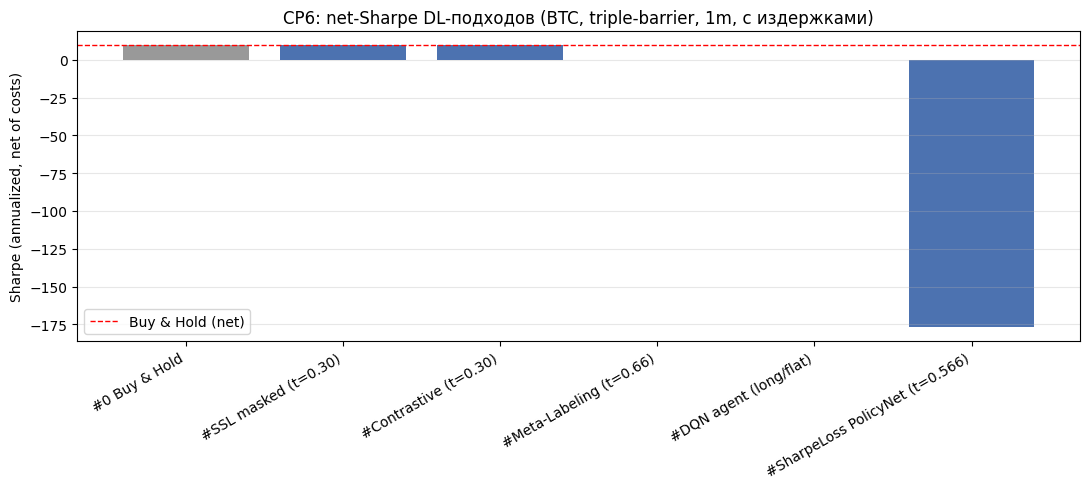

In [12]:
rows = [bh_eval, ssl_eval, con_eval, pol_eval, meta_eval, rl_eval]
summary = pd.DataFrame(rows)
cols = ["Стратегия", "Sharpe gross", "Sharpe net", "PnL net (sum logret)",
        "% времени в long", "Сделок (смен позиции)", "Вырождена?", "ROC-AUC", "Hit-rate входов"]
summary = summary[[c for c in cols if c in summary.columns]].sort_values(
    "Sharpe net", ascending=False).reset_index(drop=True)
display(summary)

# Сохраняем итоговую таблицу рядом с моделями
summary.to_csv(MODELS_DIR / "cp6_results_summary.csv", index=False)
print("\nСохранённые модели в", MODELS_DIR, ":")
for p in sorted(MODELS_DIR.glob("*")):
    print("  -", p.name)

# Барчарт net-Sharpe
fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#4C72B0" if "Buy" not in s else "#999999" for s in summary["Стратегия"]]
ax.bar(summary["Стратегия"], summary["Sharpe net"], color=colors)
ax.axhline(bh_eval["Sharpe net"], color="red", ls="--", lw=1, label="Buy & Hold (net)")
ax.set_ylabel("Sharpe (annualized, net of costs)")
ax.set_title("CP6: net-Sharpe DL-подходов (BTC, triple-barrier, 1m, с издержками)")
plt.xticks(rotation=30, ha="right")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Выводы по чекпоинту 6

В этом чекпоинте мы довели набор из бейзлайн и ML-подходов до набора с **DL-подходами**.

**Что сделано:**

1. **Реалистичная оценка с транзакционными издержками** (комиссия + проскальзывание на смену позиции). Это убрало завышенный Sharpe активных стратегий и сделало сравнение честным — пороги теперь подбираются по **net-Sharpe**, а не по F1/argmax.
2. **Self-supervised (masked reconstruction)** и **contrastive (NT-Xent / SimCLR-style)** предобучение энкодера временных рядов. Это позволяет выучить представления на огромном массиве *неразмеченных* окон и снизить переобучение слабого сигнала.
3. **Custom Differentiable Sharpe Loss** — прямая end-to-end оптимизация торговой метрики вместо CrossEntropy/MSE.
4. **Meta-Labeling (López de Prado)** — двухуровневая схема (primary направление + secondary размер позиции), снижающая число ложных сделок и просадки.
5. **Deep RL (DQN)** — агент long/flat, максимизирующий чистый PnL напрямую через награду с учётом издержек.

**Методологические принципы:**
- `StandardScaler` обучается **только на train** (без утечки);
- triple-barrier как экономически осмысленный таргет (лучший по Sharpe в пред. чекпоинте);
- early stopping по валидации; пороги/гиперпараметры — на val, итог — на test.

**Ограничения и следующие шаги:**
- RL обучен на небольшом числе эпизодов (ресурсы/VRAM); для прод-системы нужно больше эпизодов, walk-forward валидация и continuous action (размер позиции);
- стоит добавить мульти-таймфреймовые признаки и данные книги ордеров (как намечено в CP5);
- интересно сравнить с готовыми foundation-моделями временных рядов (TimesFM) в режиме zero-shot/fine-tune;
- для сервиса (цель проекта) лучшую по net-Sharpe модель можно завернуть в FastAPI и отдавать прогноз/позицию по API.

> Замечание: как и в CP5, абсолютные ROC-AUC остаются в районе 0.51–0.58 — это ожидаемо для крипторынка. Ключевая метрика применимости — **net-Sharpe с учётом издержек**, по которой и стоит ранжировать подходы.